In [ ]:
# Install required libraries
!pip install -r requirements.txt

# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Step 2: Feature Selection
We will perform feature selection with the goal of selecting the most useful variables for our model. To do this, we will use 3 selection methods and compare them using a normalized score.

### Step 2.1: Pearson Correlation
Through Pearson's correlation, we can observe the correlation that exists between two variables. The closer to 1, the more correlated the two variables are. The closer to -1, the less correlated the two variables are. This technique for observing variables only allows us to observe linear relationships between variables, which makes it necessary to use another tool for the same purpose, since curved relationships may also exist.

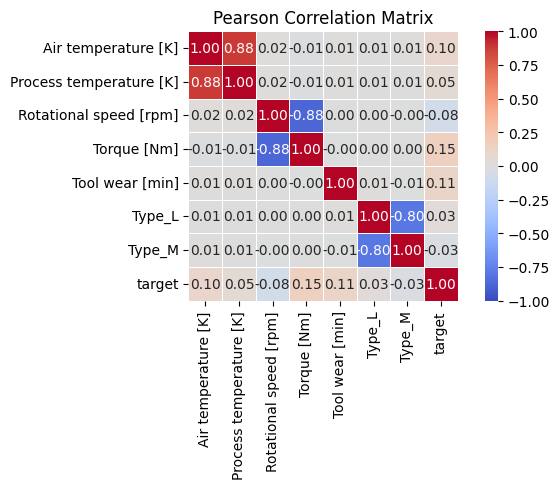

In [11]:
import pandas as pd

df = pd.read_csv("data/clean_data.csv")

X = df.drop(columns=["Failure Type"])
y = df["Failure Type"]

corr = X.copy()
corr["target"] = y

# Compute the correlation matrix (numerical columns only)
corr_matrix = corr.corr()
corr_target = corr_matrix["target"].drop("target").abs()

# Plot as a heatmap
plt.figure(figsize = (7, 5))
sns.heatmap(
    corr_matrix,
    annot = True,               # show correlation values inside cells
    fmt = '.2f',                # format : 2 decimal places
    cmap = 'coolwarm',         # blue = negative , red = positive
    vmin = -1 , vmax = 1,
    linewidths = 0.5,
    square = True
    )
plt.title('Pearson Correlation Matrix')
plt.tight_layout()
plt.show()

### Step 2.2: Mutual Information
Mutual Information (MI) is crucial for observing non-linear relationships. In these cases, we measure the uncertainty of a variable Y, knowing the value of a variable X. Thus, if the MI is zero, the variables are highly independent of each other, and as the MI moves away from zero, we can verify the degree of dependence between the variables.

In [12]:
from sklearn.feature_selection import mutual_info_classif

# Compute mutual information between each feature and the target
mi_scores = mutual_info_classif(X, y, random_state = 42)

mi_df = pd.Series(mi_scores, index = X.columns).sort_values(ascending = False)
print(mi_df)

Torque [Nm]                0.070814
Rotational speed [rpm]     0.051876
Tool wear [min]            0.025131
Air temperature [K]        0.019082
Process temperature [K]    0.009131
Type_L                     0.004887
Type_M                     0.002252
dtype: float64


### Step 2.3: Random Forest
Random Forest is a tree-based feature importance technique that relies on decision trees. Each tree makes a decision using the features, with the aim of assigning them an importance score according to their participation in the process of reducing data precision errors.

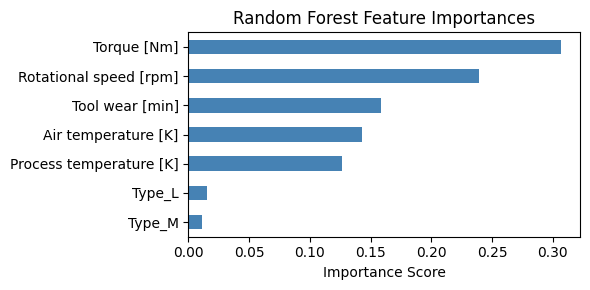

In [13]:
from sklearn.ensemble import RandomForestClassifier

# Train a Random Forest
rf = RandomForestClassifier (n_estimators = 100, random_state = 42)
rf.fit(X, y)

# Extract and plot feature importances
rf_importances = pd.Series(rf.feature_importances_, index = X.columns)
rf_importances = rf_importances.sort_values(ascending = True)

plt.figure(figsize = (6, 3))
rf_importances.plot(kind = 'barh', color = 'steelblue')
plt.title ('Random Forest Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

### Step 2.4: Normalization
To avoid the occurrence of different scales, we will normalize the scores obtained through each feature importance score tool. Thus, we will use the Min-Max method, with the aim of equalizing the three tools in a system of 0 for the minimum possible value and 1 for the maximum possible value.


In [14]:
def normalize(s):
    return (s - s.min()) / (s.max() - s.min())

corr_norm = normalize(corr_target)      # Correlation matrix score
mi_norm = normalize(mi_df)              # Mutual Infomation score
rf_norm = normalize(rf_importances)     # Random Forest score

### Step 2.5: Ranking
Based on the scores obtained, we can average the scores from each method for each feature, ensuring a more robust analysis.

In [15]:
feature_scores = pd.DataFrame({
    "Correlation": corr_norm,
    "Mutual Information": mi_norm,
    "Random Forest": rf_norm
})

feature_scores["Final Score"] = feature_scores.mean(axis=1)
feature_scores = feature_scores.sort_values("Final Score", ascending=False)
print(feature_scores)

                         Correlation  Mutual Information  Random Forest  \
Torque [Nm]                 1.000000            1.000000       1.000000   
Rotational speed [rpm]      0.441387            0.723783       0.769938   
Tool wear [min]             0.677193            0.333704       0.496836   
Air temperature [K]         0.557914            0.245473       0.445122   
Process temperature [K]     0.177999            0.100330       0.388105   
Type_L                      0.021818            0.038429       0.012804   
Type_M                      0.000000            0.000000       0.000000   

                         Final Score  
Torque [Nm]                 1.000000  
Rotational speed [rpm]      0.645036  
Tool wear [min]             0.502578  
Air temperature [K]         0.416170  
Process temperature [K]     0.222145  
Type_L                      0.024351  
Type_M                      0.000000  


### Step 2.6: Feature selection with scores
Based on the scores obtained, it was decided to remove the Type_L and Type_M columns, as they obtained very low scores, meaning they do not add much value to our dataset.

### Step 2.7: Feature selection with VIF
Finally, it is crucial that we know the VIF (Variance Inflation Factor) of the features, as a way to detect the degree of correlation between them. A VIF > 10 represents highly correlated features, which should be excluded.

We also use VIF calculation to remove redundant features where the VIF is greater than 10.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_numeric = X.select_dtypes(include=["int64", "float64"])
# Calculating the VIF
X_vif = add_constant(X_numeric)

vif = pd.DataFrame()
vif["Feature"] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif = vif[vif["Feature"] != "const"].reset_index(drop=True)
display(vif)

,Feature,VIF
0,Air temperature [K],4.303979
1,Process temperature [K],4.302788
2,Rotational speed [rpm],4.270132
3,Torque [Nm],4.268850
4,Tool wear [min],1.000237


Since no column obtained a VIF higher than 10, it was decided not to exclude columns here.